# Feature importance

This notebook loads the classifiers saved by notebook `01b` and computes feature importances using Gini impurity (spatially cross-validated) and permutation importance.

## Notebook setup

These cells set up the environment based on the selected config file.

### Config

In [5]:
config_file = "config/.run_config.yml"

In [6]:
from lib.paths import PathConfigManager
pcm = PathConfigManager(config_file, notebook="01")

# Base directories
output_dir = pcm.OUTPUT_DIR
points_data_dir = pcm.POINTS_DATA_DIR

pcm.create_directories()
pcm.FEATURE_IMPORTANCE_DIR.mkdir(parents=True, exist_ok=True)

# Input data filepaths
training_data_filepath = pcm.TRAINING_DATA_PATH

# Notebook scope
use_extracted_data = pcm.use_extracted_data
use_same_features = pcm.config["use_same_features"]
create_regional_models = pcm.config["create_regional_models"]

# Computation parameters
random_seed = pcm.config["random_seed"]
n_jobs = pcm.config["n_jobs"]
verbose = pcm.config["verbose"]
overwrite = pcm.config["overwrite_output"]

# SHAP output paths
shap_importance_path = pcm.SHAP_IMPORTANCE_PATH
shap_values_path = pcm.SHAP_VALUES_PATH
shap_estimator_path = pcm.SHAP_ESTIMATOR_PATH

### Notebook parameters

In [7]:
# Scorer for permutation importance
# "average_precision": area under the precision-recall curve
# "recall_auc": mean predicted score for known positives
#               (equivalent to AUC of recall-vs-threshold curve)
cv_scorer = "average_precision"

### Imports

In [8]:
import warnings

import joblib
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import shap
from pathlib import Path
from sklearn.base import clone
from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.inspection import permutation_importance
from sklearn.metrics import average_precision_score, make_scorer
from sklearn.model_selection import StratifiedGroupKFold

from lib.check_files import check_prepared_data
from lib.colours import FeatureSetColour
from lib.misc import format_feature_name

plt.style.use(pcm.CONFIG_DIR / "thesis.mplstyle")
pd.set_option('future.no_silent_downcasting', True)
%env PYTHONWARNINGS=ignore
warnings.simplefilter("ignore")

env: PYTHONWARNINGS=ignore


### Input and output files

In [9]:
if use_extracted_data:
    print(f"Using extracted training data in {points_data_dir}")
else:
    prep_dir = check_prepared_data(pcm.PREPARED_DATA_DIR, verbose=True)
    prep_dir = Path(prep_dir)
    training_data_filepath = prep_dir / "training_data_global.csv"

pu_basename = pcm.CLASSIFIER_PATH.with_suffix("")
importance_dir = pcm.FEATURE_IMPORTANCE_DIR
gini_importance_basename = importance_dir / "gini_importance"
selected_features_filepath = pcm.SELECTED_FEATURES_PATH

Using extracted training data in /Users/glados/Documents/Not Useless/Documents/University/2026/Honours/Data & Code/PUB-framework-Alfonso/data_extracted/zahirovic2022/polygons_points/trenches_6.0_deg_buffer


### Plotting setup

In [10]:
FW = 150 / 25.4  # Convert 150 mm to inches for figure width

label_size = 8
tick_size = 4
title_size = 10

# Feature-set colour resolver — used by all importance plots
_colour_resolver = FeatureSetColour(pcm)

In [11]:
def feature_importance_boxplot(
    importances,
    *,
    colour_resolver=None,
    topn=None,
    xlabel="Importance",
    title="",
    xmin=None,
    ax=None,
):
    """Horizontal boxplot of feature importances, optionally coloured by feature set.

    Parameters
    ----------
    importances : pd.DataFrame
        Columns = feature names, rows = sampled importance values.
    colour_resolver : FeatureSetColour, optional
        Callable mapping feature name → colour.  If None, all boxes use 'C0'.
    topn : int, optional
        Show only the top-*topn* features by median importance.
    xlabel : str
        X-axis label (e.g. "Gini importance").
    title : str
        Axes title.
    xmin : float or None
        If given, sets the left edge of the x-axis.  Pass ``0`` for Gini
        importance; leave ``None`` for permutation importance so negative
        values remain visible.
    ax : matplotlib.axes.Axes, optional
        Axes to draw into.  If None, a new figure is created.

    Returns
    -------
    fig, ax
    """
    medians = importances.median().sort_values(ascending=False)
    if topn is not None:
        medians = medians.iloc[:topn]
    ordered = list(medians.index[::-1])   # reverse → highest median at top
    n = len(ordered)

    if ax is None:
        fig, ax = plt.subplots(figsize=(FW, max(0.2 * n, 3)))
    else:
        fig = ax.figure

    bp = ax.boxplot(
        [importances[c].values for c in ordered],
        vert=False,
        patch_artist=True,
        showfliers=False,
        medianprops=dict(color="white", linewidth=1.0),
        whiskerprops=dict(linewidth=0.6),
        capprops=dict(linewidth=0.6),
        boxprops=dict(linewidth=0.6),
    )
    for patch, c in zip(bp["boxes"], ordered):
        col = colour_resolver(c) if colour_resolver is not None else "C0"
        patch.set_facecolor(col)
        patch.set_alpha(0.75)

    if colour_resolver is not None:
        ax.legend(handles=colour_resolver.legend_handles(),
                  fontsize=tick_size, loc="lower right")

    ax.set_yticks(range(1, n + 1), [format_feature_name(c) for c in ordered])
    ax.tick_params(labelsize=tick_size)
    ax.tick_params(axis="y", labelcolor="black")
    ax.grid(linestyle="dotted")
    if xmin is not None:
        ax.set_xlim(left=xmin)
    ax.set_xlabel(xlabel, fontsize=label_size)
    ax.set_ylabel("Feature", rotation=0, ha="right", fontsize=label_size)
    ax.yaxis.set_label_coords(x=-0.017, y=1.02)
    if title:
        ax.set_title(title, fontsize=title_size)

    return fig, ax

## Training data

Load the training dataset and reconstruct the feature matrix used to train the classifiers.

In [17]:
data = pd.read_csv(training_data_filepath)
data.columns

Index(['present_lon', 'present_lat', 'age (Ma)', 'Cu (Mt)', 'source', 'label',
       'plate_id', 'lon', 'lat', 'overriding_plate_id',
       ...
       'plate_transverse_velocity_upper_mantle_abs_max_value (cm/yr)',
       'plate_transverse_velocity_upper_mantle_depth_of_abs_max (km)',
       'temperature_deviation_upper_mantle_ref_value_delta (K/Myr)',
       'temperature_deviation_upper_mantle_ref_gradient_delta (K/km/Myr)',
       'temperature_deviation_upper_mantle_depth_integral_delta (K·km/Myr)',
       'temperature_deviation_upper_mantle_min_value_delta (K/Myr)',
       'temperature_deviation_upper_mantle_depth_of_min_delta (km/Myr)',
       'temperature_deviation_upper_mantle_max_value_delta (K/Myr)',
       'temperature_deviation_upper_mantle_depth_of_max_delta (km/Myr)',
       'region'],
      dtype='str', length=121)

### Columns to drop

In [18]:
# ---+ Coordinate columns --------------------------------------------------------

coordinate_columns = {
    "present_lon",
    "present_lat",
    "lon",
    "lat",
    "Cu (Mt)",
    "age (Ma)",
}


# ---+ Metadata columns --------------------------------------------------------

metadata_columns = {
    "region",
    "plate_id",
    "set",
    "source",
    "overriding_plate_id",
    "subducting_plate_ID",
    "trench_plate_ID",
    "arc_segment_length (degrees)",
    "trench_normal_angle (degrees)",
    "distance_from_trench_start (degrees)",
    "distance_from_trench_start (km)",
    "crustal_thickness_n",
    "bracket_infilled",
}


# ---+ Component columns --------------------------------------------------------

# Drop individual water/carbon components, only use totals
component_columns = {
    "base_lithosphere_water_thickness (m)",
    "sedimentary_bound_water_thickness (m)",
    "sedimentary_pore_water_thickness (m)",
    "mantle_lithosphere_water_thickness (m)",
    "crustal_pore_water_thickness (m)",
    "crustal_bound_water_thickness (m)",
    "subducted_carbonate_volume (m)",
    "carbonate_carbon_density (t/m^2)",
    "carbonate_thickness (m)",
    "crustal_carbon_density (t/m^2)",
}
# # Use orthogonal/parallel velocity vector components
# component_columns |= {
#     "subducting_plate_absolute_velocity (cm/yr)",
#     "convergence_rate (cm/yr)",
#     "trench_velocity (cm/yr)",
# }
# # Drop oceanic crust thickness and convergence rate,
# # only use slab flux (product of the two components)
# component_columns |= {
#     "convergence_rate_orthogonal (cm/yr)",
#     "plate_thickness (m)",
# }
# Drop orthogonal components of mantle/plate velocity to prevent spatial leakage;
# use only overall magnitude
component_columns |= {
    component for component in data.columns if "east" in component or "north" in component
}


# ---+ Preservation columns --------------------------------------------------------

preservation_columns = {
    "total_precipitation (km)",
    "total_convergence (km)",
    "erosion (m)",
}


# ---+ Final set for feature selection --------------------------------------------------------

columns_to_drop = coordinate_columns | metadata_columns | component_columns | preservation_columns

### Load training data

In [19]:
data = pd.read_csv(training_data_filepath)

data = data.drop_duplicates(subset=["lon", "lat", "age (Ma)"], keep="first")

# Skip regions with < 50 deposits for regional models only.
# The global model *can* train on all deposits, including those outside region polygons.
regions_to_skip = set()
for region, subset in data.groupby("region"):
    if (subset["label"] == "positive").sum() < 50:
        regions_to_skip.add(region)
data_regional = data[~data["region"].isin(regions_to_skip)]
data = data[~data["region"].isin(regions_to_skip)]

cleaned = data.drop(
    columns=list(columns_to_drop),
    errors="ignore",
)

print("Training data summary (global):")
print(data.groupby(["region", "label"]).size())

Training data summary (global):
region          label     
East Asia       negative         7
                positive       140
                unlabelled    5223
North America   negative        51
                positive       283
                unlabelled    6020
South America   negative       641
                positive       160
                unlabelled    6081
Southeast Asia  negative         2
                positive       123
                unlabelled    3927
Tethys          negative         5
                positive       281
                unlabelled    4831
dtype: int64


### Wrangle training data

In [20]:
data_pu = data[data["label"].isin({"positive", "unlabelled"})]

train_pu = cleaned[cleaned["label"].isin({"positive", "unlabelled"})]
features_pu = train_pu.drop(columns="label")
y_pu = train_pu["label"].replace({"positive": 1, "unlabelled": 0}).astype("int")

selected_features = pd.read_csv(selected_features_filepath)["selected_features"].tolist()
X_pu = features_pu[selected_features]

## Define spatial folds

Spatial folds divide training data into 10° × 10° × 10 Myr voxels, matching the fold design used for hyperparameter tuning in notebook `01b`.

In [21]:
lon_spacing, lat_spacing, time_spacing = 10, 10, 10

lon_grid = np.floor(data_pu["lon"] / lon_spacing) * lon_spacing
lat_grid = np.floor(data_pu["lat"] / lat_spacing) * lat_spacing
time_grid = np.floor(data_pu["age (Ma)"] / time_spacing) * time_spacing

spatial_groups, _ = pd.factorize(lon_grid + lat_grid * 100 + time_grid * 10000)

n_folds_spatial = 5
sgkf = StratifiedGroupKFold(n_splits=n_folds_spatial, shuffle=True, random_state=random_seed)

## Load classifier

Load the global PU classifier fitted in notebook `01b`.

In [22]:
pu_pipeline = joblib.load(pu_basename.with_suffix(".joblib"))
print(f"Loaded classifier from {pu_basename.with_suffix(".joblib")}")
display(pu_pipeline)

Loaded classifier from /Users/glados/Documents/Not Useless/Documents/University/2026/Honours/Data & Code/PUB-framework-Alfonso/output/all_features/classifier.joblib


,steps,"[('preprocessing', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,steps,"[('robustscaler', ...), ('variancethreshold', ...)]"
,transform_input,None
,memory,None
,verbose,False
,with_centering,True
,with_scaling,True
,quantile_range,"(25.0, ...)"


## Gini importance

Mean decrease in impurity (Gini) across spatial CV folds. Each fold refits the full pipeline on the training split and stacks importances from all inner bags, giving a distribution over spatial and bootstrap subsampling variance.

### Global model

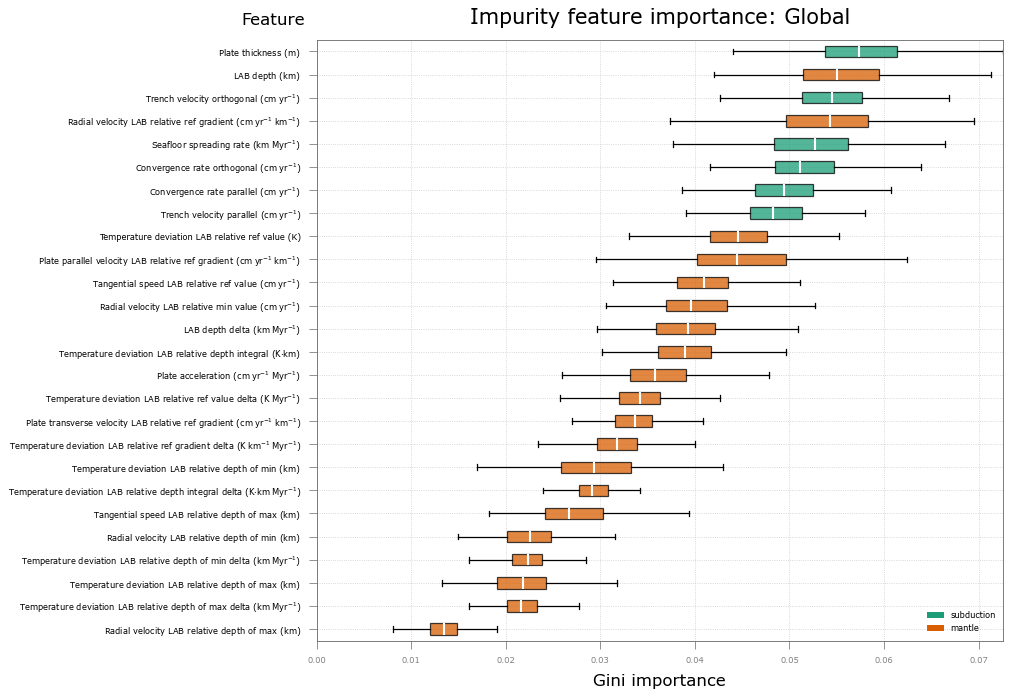

In [15]:
feature_names = pu_pipeline.feature_names_in_

replace = {"positive": 1, "negative": 0, "unlabelled": 0}
importances = []
for train_idx, _ in sgkf.split(X_pu, y_pu, groups=spatial_groups):
    X_train = X_pu.iloc[train_idx]
    y_train = y_pu.iloc[train_idx]

    clf = clone(pu_pipeline)
    clf.fit(X_train, y_train)
    df_results = pd.DataFrame(
        np.vstack(
            [
                i.feature_importances_
                for i in clf["classifier"].estimators_
            ]
        ),
        columns=clf["preprocessing"].get_feature_names_out(),
    )
    importances.append(df_results)
importances = pd.concat(importances, ignore_index=True)
importances = importances[
    importances.median().sort_values(ascending=False).index
]
importances.to_csv(gini_importance_basename.with_suffix(".csv"), index=False)

fig, ax = feature_importance_boxplot(
    importances,
    colour_resolver=_colour_resolver,
    xlabel="Gini importance",
    title="Impurity feature importance: Global",
    xmin=0,
)
for ext in (".pdf", ".png"):
    fig.savefig(gini_importance_basename.with_suffix(ext), dpi=350, bbox_inches="tight")

### Regional models

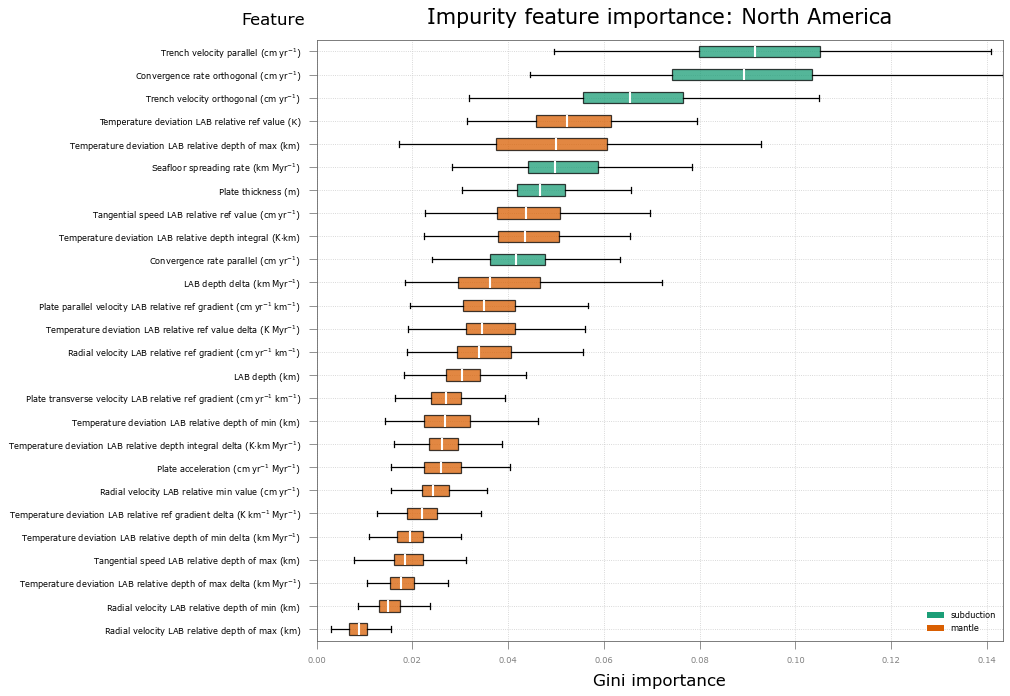

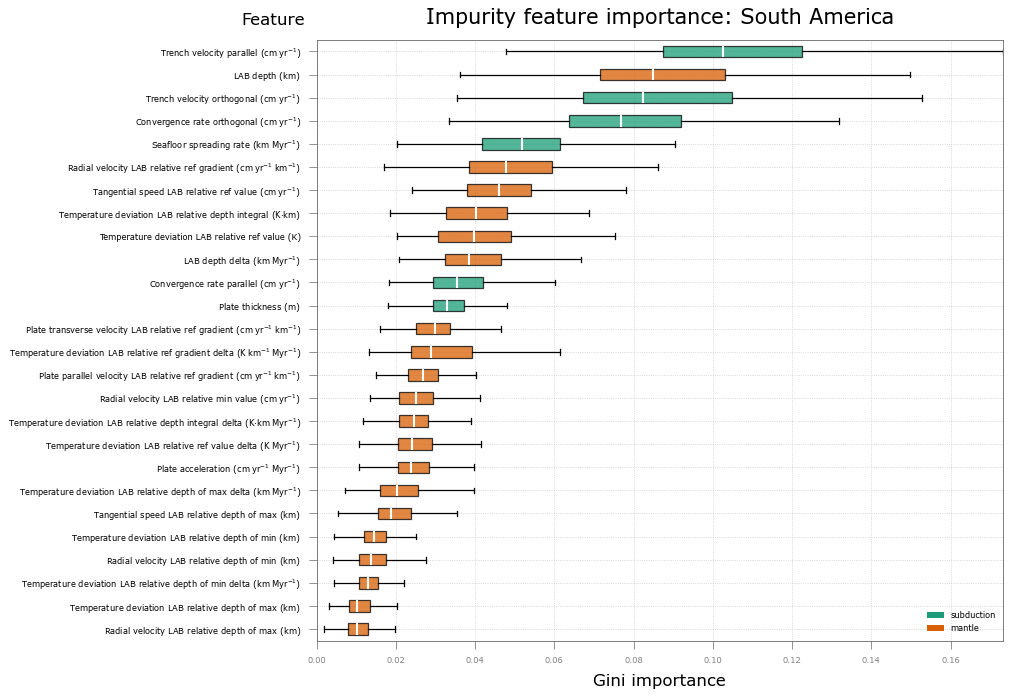

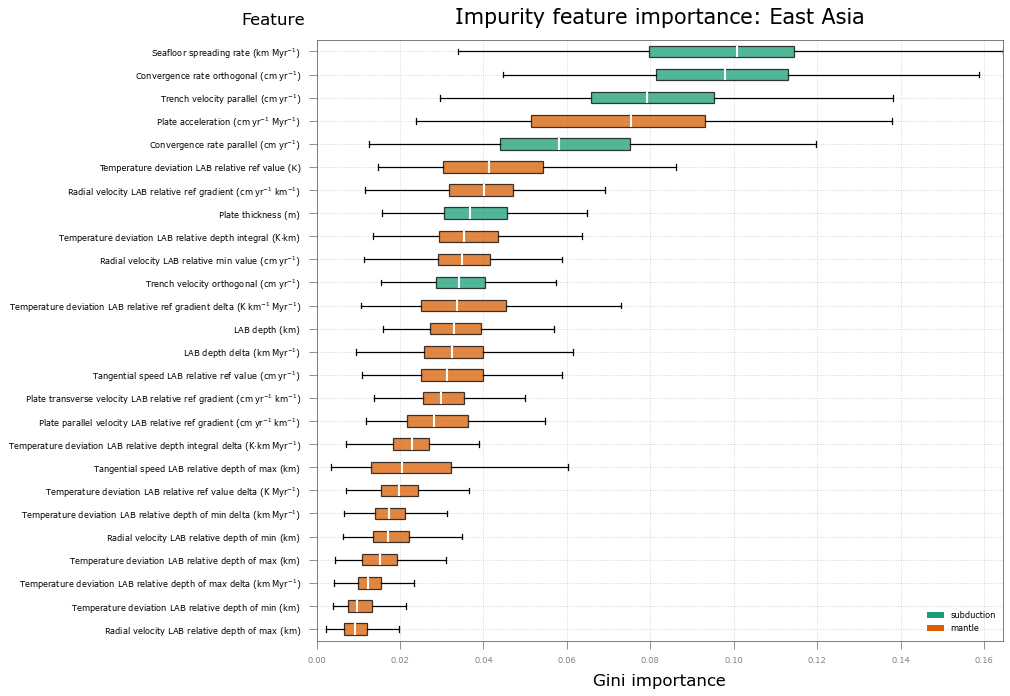

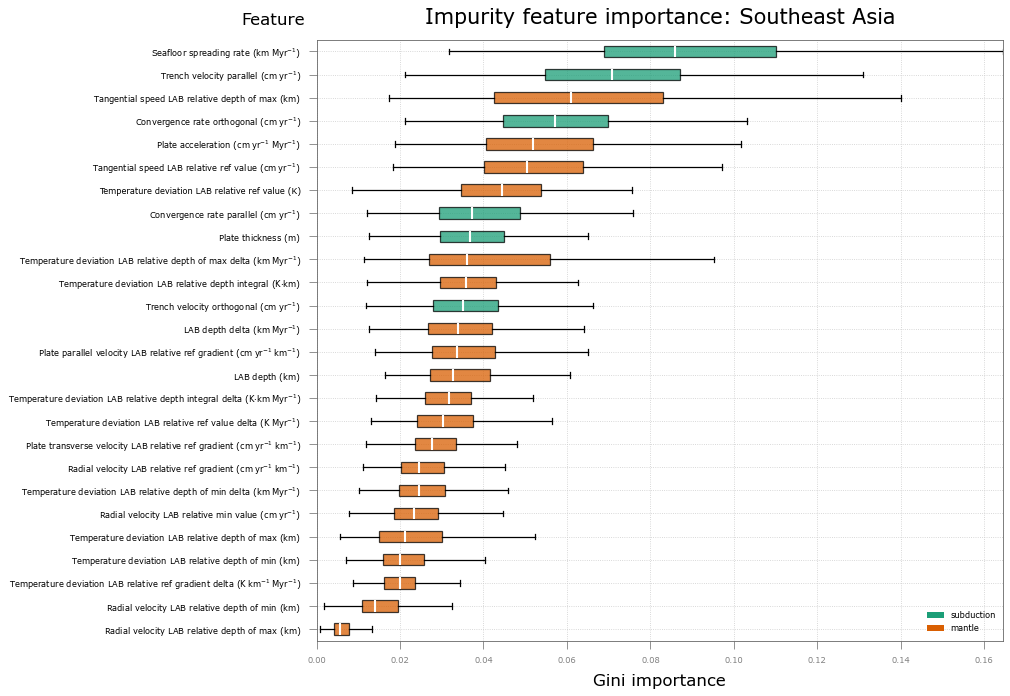

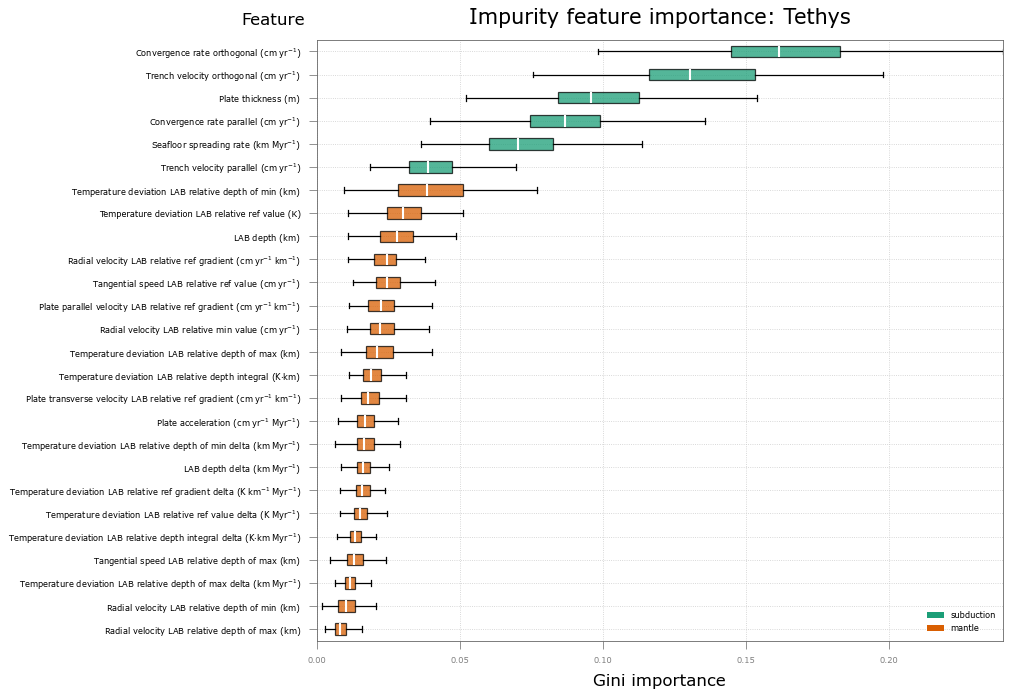

In [16]:
if create_regional_models:
    for region in data_regional["region"].unique():
        r = "_".join(region.lower().split())
        subset = data_regional[data_regional["region"] == region]
        subset = subset[subset["label"].isin({"positive", "unlabelled"})]

        model_path = f"{pu_basename}_{r}.joblib"
        try:
            model = joblib.load(model_path)
        except FileNotFoundError:
            raise RuntimeError(
                f"No fitted model found for {region} at {model_path}. "
                "Run the 'Train and save classifiers' section of notebook 01b first."
            )

        region_features_path = selected_features_filepath.with_name(
            f"{selected_features_filepath.stem}_{region.lower().replace(' ', '_')}.csv"
        )
        region_features = pd.read_csv(region_features_path)["selected_features"].tolist()

        train_pu_region = cleaned[
            (cleaned.index.isin(subset.index)) & (cleaned["label"] != "negative")
        ]
        X_pu_region = train_pu_region[region_features]
        y_pu_region = train_pu_region["label"].replace(replace).infer_objects()

        spatial_groups_region, _ = pd.factorize(
            np.floor(subset["lon"] / 10) * 10
            + np.floor(subset["lat"] / 10) * 100
            + np.floor(subset["age (Ma)"] / 10) * 10000
        )
        sgkf_region = StratifiedGroupKFold(n_splits=n_folds_spatial, shuffle=True, random_state=random_seed)

        importances = []
        for train_idx, _ in sgkf_region.split(X_pu_region, y_pu_region, groups=spatial_groups_region):
            X_train = X_pu_region.iloc[train_idx]
            y_train = y_pu_region.iloc[train_idx]
            clf = clone(model)
            clf.fit(X_train, y_train)
            df_results = pd.DataFrame(
                np.vstack([i.feature_importances_ for i in clf["classifier"].estimators_]),
                columns=clf["preprocessing"].get_feature_names_out(),
            )
            importances.append(df_results)
        importances = pd.concat(importances, ignore_index=True)
        importances = importances[
            importances.median().sort_values(ascending=False).index
        ]
        importances.to_csv(f"{gini_importance_basename}_{r}.csv", index=False)

        fig, ax = feature_importance_boxplot(
            importances,
            colour_resolver=_colour_resolver,
            xlabel="Gini importance",
            title=f"Impurity feature importance: {region}",
            xmin=0,
        )
        for ext in (".pdf", ".png"):
            fig.savefig(f"{gini_importance_basename}_{r}{ext}", dpi=350, bbox_inches="tight")

## Permutation importance

Permutation importance is computed by measuring how much the model score drops when a feature is randomly shuffled. Unlike Gini impurity, it is evaluated on held-out data and reflects generalisation. Spatial folds are used to reduce optimistic bias from spatially autocorrelated features.

The scorer is controlled by the `cv_scorer` parameter set above.

### Global model

In [ ]:
def _recall_auc(y_true, y_score):
    """Mean predicted score for positives — equivalent to AUC of recall-vs-threshold curve."""
    return float(np.mean(y_score[y_true == 1]))

# Use plain callables rather than make_scorer/string scorers — newer sklearn versions
# fail to recognise BaggingPuClassifier inside a Pipeline as a classifier, causing
# check_scoring to reject predict_proba. Calling it directly bypasses is_classifier().
if cv_scorer == "average_precision":
    def perm_scorer(estimator, X, y):
        return average_precision_score(y, estimator.predict_proba(X)[:, 1])
elif cv_scorer == "recall_auc":
    def perm_scorer(estimator, X, y):
        return _recall_auc(y, estimator.predict_proba(X)[:, 1])
else:
    raise ValueError(f"Unknown cv_scorer: {cv_scorer!r}. Use 'average_precision' or 'recall_auc'.")

perm_importances_list = []
for fold, (train_idx, test_idx) in enumerate(sgkf.split(X_pu, y_pu, groups=spatial_groups)):
    X_train, y_train = X_pu.iloc[train_idx], y_pu.iloc[train_idx]
    X_test, y_test = X_pu.iloc[test_idx], y_pu.iloc[test_idx]
    print(f"Fold {fold + 1}/{n_folds_spatial}")
    clf = clone(pu_pipeline)
    clf.fit(X_train, y_train)
    result = permutation_importance(
        clf, X_test, y_test,
        scoring=perm_scorer,
        n_repeats=10,
        random_state=random_seed,
        n_jobs=n_jobs,
    )
    # result.importances shape: (n_features, n_repeats)
    perm_importances_list.append(
        pd.DataFrame(result.importances.T, columns=X_pu.columns)
    )

perm_importances = pd.concat(perm_importances_list, ignore_index=True)
perm_importances = perm_importances[
    perm_importances.median().sort_values(ascending=False).index
]
perm_importances.to_csv(
    importance_dir / f"permutation_importance_{cv_scorer}.csv", index=False
)

fig, ax = feature_importance_boxplot(
    perm_importances,
    colour_resolver=_colour_resolver,
    xlabel=f"Permutation importance ({cv_scorer})",
    title="Permutation feature importance: Global",
)
ax.axvline(0, color="0.4", linestyle="--", linewidth=0.8)
for ext in (".pdf", ".png"):
    fig.savefig(
        importance_dir / f"permutation_importance_{cv_scorer}{ext}",
        dpi=350,
        bbox_inches="tight",
    )

## SHAP importance

SHAP (SHapley Additive exPlanations) values are computed by applying `TreeExplainer` to each of the 50 base `RandomForestClassifier` estimators inside the fitted `BaggingPuClassifier`, then averaging the resulting per-sample matrices. This gives a single SHAP matrix of shape *(n_samples × n_features)* that reflects both bagging and within-forest variance.

Two views are saved:
- **Bar plot** — mean |SHAP| per feature, sorted descending; directly comparable to gini/permutation rankings.
- **Beeswarm** — each dot is one training sample; colour encodes raw feature value (high = red, low = blue), position on x-axis encodes impact on model output.

Raw (pre-scaling) feature values are used for beeswarm colouring — `VarianceThreshold` drops no features so the column order is identical to the preprocessed input the trees see.

### Global model

In [ ]:
use_grid = False
if use_grid:
    # Load grid data and select the same features used by the model
    grid_data = pd.read_csv(pcm.GRID_DATA_PATH)
    X_grid = grid_data[selected_features]       # grid has no label/metadata cols; select directly
    X_grid_pre = pu_pipeline["preprocessing"].transform(X_grid)

    if X_grid_pre.shape[1] != X_grid.shape[1]:
        raise AssertionError(
            f"VarianceThreshold dropped {X_grid.shape[1] - X_grid_pre.shape[1]} feature(s) "
            f"({X_grid.shape[1]} in → {X_grid_pre.shape[1]} out). "
            "Scaled X_grid_pre cannot be used for beeswarm colouring — review the pipeline."
        )

    feature_names_shap = list(X_grid.columns)   # == selected_features; VT drops nothing
    X_shap_pre = X_grid_pre
else:
    feature_names_shap = list(X_pu.columns)
    X_pu_pre = pu_pipeline["preprocessing"].transform(X_pu)
    X_shap_pre = X_pu_pre

# Cache: skip expensive SHAP computation if results already exist on disk
if shap_values_path.exists() and shap_estimator_path.exists() and not overwrite:
    print(f"Loading cached SHAP values from {shap_values_path}")
    shap_df = pd.read_csv(shap_values_path)
    shap_estimator_df = pd.read_csv(shap_estimator_path)
else:
    # Background: summarise scaled training data into 100 weighted centroids.
    # Passing the full X_pre (thousands of rows) per estimator would be too slow.
    X_pre = pu_pipeline["preprocessing"].transform(X_pu)
    background = shap.kmeans(X_pre, 100)

    # Explain over grid (or training) data, accumulating the mean incrementally to avoid
    # stacking 50 large (n_grid × n_features) matrices simultaneously.
    # Note: background.data extracts the numpy centroid array from the legacy
    # DenseData wrapper — required by TreeExplainer in newer SHAP versions.
    n_estimators = len(pu_pipeline["classifier"].estimators_)
    mean_shap = np.zeros((len(X_shap_pre), X_shap_pre.shape[1]))
    shap_rows = []
    for i, estimator in enumerate(pu_pipeline["classifier"].estimators_):
        print(f"  Estimator {i + 1}/{n_estimators}", end="\r")
        explainer = shap.TreeExplainer(estimator, data=background.data)
        sv = explainer.shap_values(X_shap_pre, check_additivity=False)
        if isinstance(sv, list):
            sv = sv[1]
        mean_shap += sv / n_estimators
        shap_rows.append(np.abs(sv).mean(axis=0))
    print()

    shap_df = pd.DataFrame(mean_shap, columns=feature_names_shap)
    shap_df.to_csv(shap_values_path, index=False)

    shap_estimator_df = pd.DataFrame(shap_rows, columns=feature_names_shap)
    shap_estimator_df.to_csv(shap_estimator_path, index=False)

# Mean |SHAP| summary — always recomputed (cheap) so plots reflect the loaded data
mean_abs_shap = shap_df.abs().mean().sort_values(ascending=False)
mean_abs_shap.to_csv(shap_importance_path, header=["mean_abs_shap"])

# --- Bar plot: mean |SHAP| per feature ---
fig, ax = feature_importance_boxplot(
    shap_df,
    colour_resolver=_colour_resolver,
    xlabel="Mean |SHAP value|",
    title="SHAP feature importance: Global",
    xmin=0,
)
for ext in (".pdf", ".png"):
    fig.savefig(importance_dir / f"shap_importance{ext}", dpi=350, bbox_inches="tight")

# --- Beeswarm: full SHAP distribution ---
explanation = shap.Explanation(
    values=shap_df.values,
    data=X_shap_pre,                    # scaled values drive dot colouring
    feature_names=[format_feature_name(f) for f in feature_names_shap],
)
shap.plots.beeswarm(explanation, show=False)
fig_beeswarm = plt.gcf()
for ext in (".pdf", ".png"):
    fig_beeswarm.savefig(importance_dir / f"shap_beeswarm{ext}", dpi=350, bbox_inches="tight")
plt.close()

100%|===================| 54123/54138 [04:20<00:00]        

ExplainerError: Additivity check failed in TreeExplainer! Please ensure the data matrix you passed to the explainer is the same shape that the model was trained on. If your data shape is correct then please report this on GitHub. This check failed because for one of the samples the sum of the SHAP values was 0.651652, while the model output was 0.681329. If this difference is acceptable you can set check_additivity=False to disable this check.

### Regional models

In [ ]:
if create_regional_models:
    for region in data_regional["region"].unique():
        r = "_".join(region.lower().split())
        subset = data_regional[data_regional["region"] == region]
        subset = subset[subset["label"].isin({"positive", "unlabelled"})]

        model_path = f"{pu_basename}_{r}.joblib"
        try:
            model = joblib.load(model_path)
        except FileNotFoundError:
            raise RuntimeError(
                f"No fitted model found for {region} at {model_path}. "
                "Run the 'Train and save classifiers' section of notebook 01b first."
            )

        region_features_path = selected_features_filepath.with_name(
            f"{selected_features_filepath.stem}_{region.lower().replace(' ', '_')}.csv"
        )
        region_features = pd.read_csv(region_features_path)["selected_features"].tolist()

        train_pu_region = cleaned[
            (cleaned.index.isin(subset.index)) & (cleaned["label"] != "negative")
        ]
        X_pu_region = train_pu_region[region_features]

        X_grid_region = grid_data[grid_data["region"] == region][region_features]
        X_grid_pre_region = model["preprocessing"].transform(X_grid_region)

        if X_grid_pre_region.shape[1] != X_grid_region.shape[1]:
            raise AssertionError(
                f"[{region}] VarianceThreshold dropped "
                f"{X_grid_region.shape[1] - X_grid_pre_region.shape[1]} feature(s) "
                f"({X_grid_region.shape[1]} in → {X_grid_pre_region.shape[1]} out). "
                "Review the pipeline."
            )

        region_sv_path = shap_values_path.with_name(f"shap_values_{r}.csv")
        if region_sv_path.exists() and not overwrite:
            print(f"Loading cached SHAP values for {region} from {region_sv_path}")
            shap_df_region = pd.read_csv(region_sv_path)
        else:
            X_pre_region = model["preprocessing"].transform(X_pu_region)
            background_region = shap.kmeans(X_pre_region, 100)

            n_est_r = len(model["classifier"].estimators_)
            mean_shap_region = np.zeros((len(X_grid_region), X_grid_pre_region.shape[1]))
            print(f"{region}:")
            for i, estimator in enumerate(model["classifier"].estimators_):
                print(f"  Estimator {i + 1}/{n_est_r}", end="\r")
                # background_region.data: extract numpy array from legacy DenseData wrapper
                explainer = shap.TreeExplainer(estimator, data=background_region.data)
                sv = explainer.shap_values(X_grid_pre_region)
                if isinstance(sv, list):
                    sv = sv[1]
                mean_shap_region += sv / n_est_r
            print()

            shap_df_region = pd.DataFrame(mean_shap_region, columns=region_features)
            shap_df_region.to_csv(region_sv_path, index=False)

        mean_abs_region = shap_df_region.abs().mean().sort_values(ascending=False)
        mean_abs_region.to_csv(
            shap_importance_path.with_name(f"shap_importance_{r}.csv"),
            header=["mean_abs_shap"],
        )

        # Bar plot
        n_feat_r = len(region_features)
        sorted_idx_r = mean_abs_region.index.tolist()
        fig, ax = plt.subplots(figsize=(FW, max(0.2 * n_feat_r, 3)))
        _bar_colours_r = [_colour_resolver(f) for f in sorted_idx_r[::-1]]
        ax.barh(range(n_feat_r), mean_abs_region.values[::-1], color=_bar_colours_r)
        ax.legend(handles=_colour_resolver.legend_handles(), fontsize=tick_size, loc="lower right")
        ax.set_yticks(range(n_feat_r))
        ax.set_yticklabels([format_feature_name(f) for f in sorted_idx_r[::-1]])
        ax.tick_params(axis="y", labelcolor="black")
        ax.tick_params(labelsize=tick_size)
        ax.grid(linestyle="dotted")
        ax.set_xlim(0)
        ax.set_xlabel("Mean |SHAP value|", fontsize=label_size)
        ax.set_ylabel("Feature", rotation=0, ha="right", fontsize=label_size)
        ax.yaxis.set_label_coords(x=-0.017, y=1.02)
        ax.set_title(f"SHAP feature importance: {region}", fontsize=title_size)
        for ext in (".pdf", ".png"):
            fig.savefig(importance_dir / f"shap_importance_{r}{ext}", dpi=350, bbox_inches="tight")
        plt.close()

        # Beeswarm
        explanation_r = shap.Explanation(
            values=shap_df_region.values,
            data=X_grid_pre_region,     # scaled values drive dot colouring
            feature_names=[format_feature_name(f) for f in region_features],
        )
        shap.plots.beeswarm(explanation_r, show=False)
        fig_beeswarm_r = plt.gcf()
        for ext in (".pdf", ".png"):
            fig_beeswarm_r.savefig(
                importance_dir / f"shap_beeswarm_{r}{ext}", dpi=350, bbox_inches="tight"
            )
        plt.close()

## Feature distribution violin plots

Split violin plots showing how each feature's values are distributed across the
Positive (deposit) and Unlabelled classes, broken down by metallogenic province.
Left half = Positive class; right half = Unlabelled class.
Violin width is count-normalised — narrower means fewer samples.
Features are ranked by Gini importance (most important top-left).

In [ ]:
from lib.feature_importance import plot_feature_violin_grid

# Grid (deployment) data — optional; fall back gracefully if not yet extracted
try:
    grid_data_vp = pd.read_csv(pcm.GRID_DATA_PATH)
except FileNotFoundError:
    grid_data_vp = None

# Categories: overall + five metallogenic provinces
violin_categories = [
    "Overall",
    "East Asia",
    "Southeast Asia",
    "Tethys",
    "North America",
    "South America",
]

# Load Gini importance rankings (columns sorted by median importance)
gini_importances = pd.read_csv(gini_importance_basename.with_suffix(".csv"))

# Multi-panel violin grid — top features ranked by Gini importance
violin_layout = (4, 3)   # 12 panels; adjust to taste
violin_fig = plot_feature_violin_grid(
    feature_importances=gini_importances,
    layout=violin_layout,
    categories=violin_categories,
    training_data=data,   # loaded earlier in this notebook
    data_source="training" if grid_data_vp is None else "deployment",
    deployment_data=grid_data_vp,
)
violin_filename = importance_dir / "feature_violin_grid"
for ext in (".pdf", ".png"):
    violin_fig.savefig(violin_filename.with_suffix(ext), dpi=400, bbox_inches="tight")
violin_fig.show()